In [5]:
# Tested Environment: Python 3.8, PyTorch 1.9.0+

In [6]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [7]:
import torch
import torch.nn as nn
from arc.api.bulletproof import protect, BulletproofConfig

# Simple Model & Optimizer
model = nn.Linear(10, 2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Wrap it with the modern Bulletproof API
config = BulletproofConfig(verbose=True)
config.rollback_config.loss_explosion_threshold = 1000.0 

# protect() wraps the model and returns the Bulletproof controller
model, controller = protect(model, optimizer, config=config)

print("ARC Bulletproof Controller Initialized.")

OOMRecoveryHandler initialized
   Device: cpu
   Checkpointable modules: 0
   WeightRollback: Initial checkpoint saved (with RNG state)
 HardwareRecoveryHandler initialized
   Primary device: cpu
   Fallback device: cpu
BulletproofTrainer Initialized
   Device: cpu
   OOM Recovery: ✓
   Numeric Recovery: ✓
   Silent Detection: ✓
   Hardware Recovery: ✓
   Model Memory: 0.00 GB estimated
ARC Bulletproof Controller Initialized.


In [8]:
losses = []
print("Starting training loop...")

for step in range(20):
    x, y = torch.randn(5, 10), torch.randn(5, 2)
    loss = nn.MSELoss()(model(x), y)
    
    # THE SABOTAGE: Force a loss explosion at step 10
    if step == 10:
        print(f"\n[Step {step}] Injecting massive loss spike (x100,000)!")
        loss = loss * 1e5 
        
    # Hand the loss to ARC's numeric recovery module
    action = controller.rollback.step(loss)
    
    # Check if ARC intervened
    if not getattr(action, 'rolled_back', False):
        loss.backward()
        optimizer.step()
        optimizer.zero_grad() # Always zero gradients after step
        losses.append(loss.item())
        print(f"Step {step}: Loss = {loss.item():.4f}")
    else:
        print(f"ARC intervened at step {step}! Rolled back and reduced LR.")
        optimizer.zero_grad() 
        losses.append(losses[-1] if losses else float("nan")) # Keep the previous valid loss for our graph

Starting training loop...
Step 0: Loss = 1.1096
Step 1: Loss = 1.3308
Step 2: Loss = 1.7599
Step 3: Loss = 0.7143
Step 4: Loss = 1.9747
Step 5: Loss = 1.0582
Step 6: Loss = 0.8614
Step 7: Loss = 1.1796
Step 8: Loss = 3.4353
Step 9: Loss = 0.5638

[Step 10] Injecting massive loss spike (x100,000)!
  Rolled back 11 steps to step 0 (RNG restored)
  Reduced LR to 5.00e-03
  Rollback #1: loss_explosion
ARC intervened at step 10! Rolled back and reduced LR.
Step 11: Loss = 1.1096
Step 12: Loss = 1.3187
Step 13: Loss = 1.7737
Step 14: Loss = 0.7196
Step 15: Loss = 1.9959
Step 16: Loss = 1.0693
Step 17: Loss = 0.8840
Step 18: Loss = 1.2996
Step 19: Loss = 3.5354


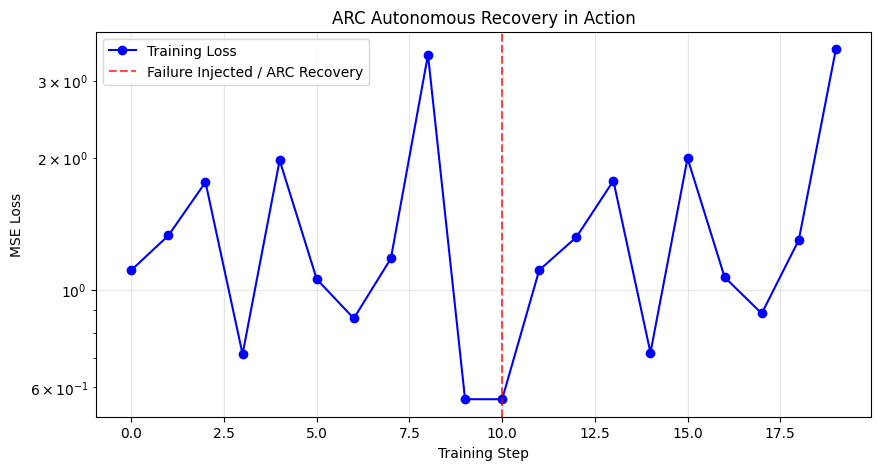

In [9]:
# Plotting the loss trajectory
plt.figure(figsize=(10, 5))
plt.plot(range(20), losses, marker='o', linestyle='-', color='b', label='Training Loss')

plt.axvline(x=10, color='r', linestyle='--', alpha=0.7, label='Failure Injected / ARC Recovery')

plt.title("ARC Autonomous Recovery in Action")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()